<a href="https://colab.research.google.com/github/krishikasahni/Deep-Learning/blob/main/exp9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.30MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 64.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.4MB/s]


Epoch 1: G=1369.14, D=134.76


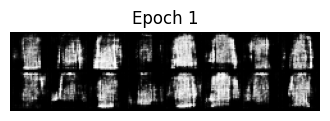

Epoch 2: G=1393.35, D=120.85


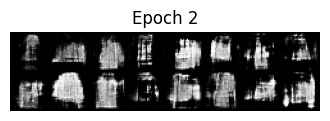

Epoch 3: G=1304.06, D=127.51


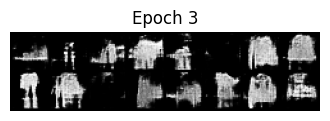

Epoch 4: G=1130.87, D=195.40


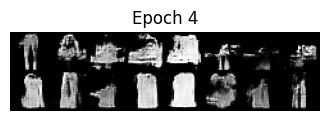

Epoch 5: G=1017.13, D=225.74


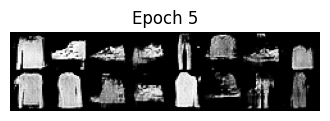

Epoch 6: G=988.53, D=238.25


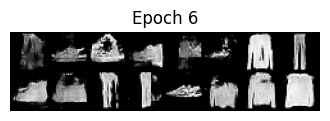

Epoch 7: G=978.89, D=243.27


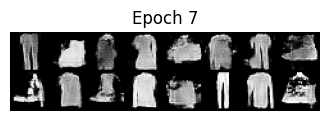

Epoch 8: G=977.56, D=243.51


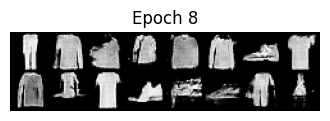

Epoch 9: G=980.01, D=241.79


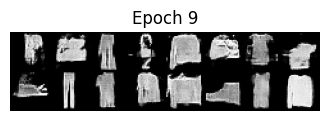

Epoch 10: G=1000.85, D=240.95


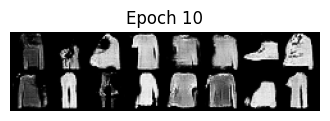

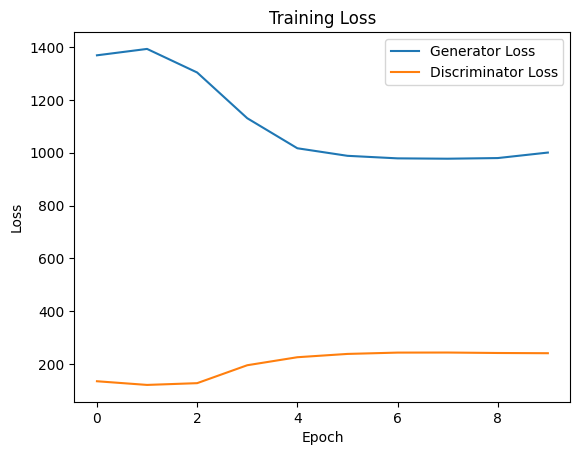

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
latent_dim = 100
epochs = 10
lr = 0.0002

use_dcgan = True
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

#VANILLA GAN

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1,1,28,28)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x.view(-1,784))

#DCGAN

class DCGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128*7*7),
            nn.ReLU(),
            nn.Unflatten(1, (128,7,7)),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64,1,4,2,1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128*7*7,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

if use_dcgan:
    G = DCGenerator().to(device)
    D = DCDiscriminator().to(device)
else:
    G = Generator().to(device)
    D = Discriminator().to(device)

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

g_losses = []
d_losses = []

def train():
    for epoch in range(epochs):
        total_g, total_d = 0, 0

        for x, _ in loader:
            x = x.to(device)
            b = x.size(0)

            real = torch.ones(b,1).to(device)
            fake = torch.zeros(b,1).to(device)

            # ---- Train Discriminator ----
            z = torch.randn(b, latent_dim).to(device)
            fake_imgs = G(z)

            d_loss = criterion(D(x), real) + criterion(D(fake_imgs.detach()), fake)

            opt_D.zero_grad()
            d_loss.backward()
            opt_D.step()

            # ---- Train Generator ----
            z = torch.randn(b, latent_dim).to(device)
            gen_imgs = G(z)

            g_loss = criterion(D(gen_imgs), real)

            opt_G.zero_grad()
            g_loss.backward()
            opt_G.step()

            total_g += g_loss.item()
            total_d += d_loss.item()

        g_losses.append(total_g)
        d_losses.append(total_d)

        print(f"Epoch {epoch+1}: G={total_g:.2f}, D={total_d:.2f}")

        show_images(epoch)

def show_images(epoch):
    G.eval()
    z = torch.randn(16, latent_dim).to(device)

    with torch.no_grad():
        samples = G(z).cpu()

    grid = vutils.make_grid(samples, normalize=True)

    plt.figure(figsize=(4,4))
    plt.imshow(grid.permute(1,2,0))
    plt.title(f"Epoch {epoch+1}")
    plt.axis("off")
    plt.show()

    G.train()

train()
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.legend()
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

torch.save(G.state_dict(), "generator.pth")
torch.save(D.state_dict(), "discriminator.pth")